In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger les données nettoyées
df = pd.read_parquet("../data/processed/hopitaux_clean.parquet")
print(df.shape)
print(df.head())

(21726, 11)
   reg       jour  PourAvec  tx_indic_7J_DC  tx_indic_7J_hosp  tx_indic_7J_SC  \
0    1 2020-03-07         0             0.0               0.0             0.0   
1    1 2020-03-08         0             0.0               0.0             0.0   
2    1 2020-03-09         0             0.0               0.0             0.0   
3    1 2020-03-10         0             0.0               0.0             0.0   
4    1 2020-03-11         0             0.0               0.0             0.0   

   tx_prev_hosp  tx_prev_SC  annee  mois  semaine  
0           0.0         0.0   2020     3       10  
1           0.0         0.0   2020     3       10  
2           0.0         0.0   2020     3       11  
3           0.0         0.0   2020     3       11  
4           0.0         0.0   2020     3       11  


In [2]:
# Travailler sur une seule région pour commencer : Île-de-France (code 11)
df_idf = df[df["reg"] == 11].copy()
df_idf = df_idf.sort_values("jour").reset_index(drop=True)

print(f"Nombre de jours : {len(df_idf)}")
print(f"Du {df_idf['jour'].min()} au {df_idf['jour'].max()}")

Nombre de jours : 1207
Du 2020-03-07 00:00:00 au 2023-06-26 00:00:00


In [3]:
# Créer les lags (valeurs passées)
df_idf["lag_1"] = df_idf["tx_prev_SC"].shift(1)   # valeur d'hier
df_idf["lag_7"] = df_idf["tx_prev_SC"].shift(7)   # valeur il y a 7 jours
df_idf["lag_14"] = df_idf["tx_prev_SC"].shift(14) # valeur il y a 14 jours

# Créer les rolling features (moyennes glissantes)
df_idf["rolling_7"] = df_idf["tx_prev_SC"].rolling(7).mean()   # moyenne 7 derniers jours
df_idf["rolling_14"] = df_idf["tx_prev_SC"].rolling(14).mean() # moyenne 14 derniers jours

# La cible : tx_prev_SC dans 7 jours
df_idf["cible"] = df_idf["tx_prev_SC"].shift(-7)

print(df_idf[["jour", "tx_prev_SC", "lag_1", "lag_7", "rolling_7", "cible"]].head(20))

         jour  tx_prev_SC      lag_1     lag_7  rolling_7      cible
0  2020-03-07    0.171035        NaN       NaN        NaN   1.376422
1  2020-03-08    0.236191   0.171035       NaN        NaN   1.881382
2  2020-03-09    0.358358   0.236191       NaN        NaN   2.435208
3  2020-03-10    0.439804   0.358358       NaN        NaN   3.217081
4  2020-03-11    0.545682   0.439804       NaN        NaN   3.754619
5  2020-03-12    0.741150   0.545682       NaN        NaN   4.805261
6  2020-03-13    0.830740   0.741150       NaN   0.474709   6.002504
7  2020-03-14    1.376422   0.830740  0.171035   0.646907   6.939122
8  2020-03-15    1.881382   1.376422  0.236191   0.881934   8.030487
9  2020-03-16    2.435208   1.881382  0.358358   1.178627   9.757123
10 2020-03-17    3.217081   2.435208  0.439804   1.575381  11.092822
11 2020-03-18    3.754619   3.217081  0.545682   2.033800  12.338932
12 2020-03-19    4.805261   3.754619  0.741150   2.614388  13.788655
13 2020-03-20    6.002504   4.8052

In [4]:
# Supprimer les lignes avec des NaN
df_idf = df_idf.dropna()
print(f"Taille après suppression des NaN : {len(df_idf)}")

Taille après suppression des NaN : 1186


In [5]:
# Découpage temporel : train = 2020-2022, test = 2023
train = df_idf[df_idf["annee"] < 2023]
test = df_idf[df_idf["annee"] == 2023]

print(f"Train : {len(train)} lignes ({train['jour'].min().date()} → {train['jour'].max().date()})")
print(f"Test  : {len(test)} lignes ({test['jour'].min().date()} → {test['jour'].max().date()})")

Train : 1016 lignes (2020-03-21 → 2022-12-31)
Test  : 170 lignes (2023-01-01 → 2023-06-19)


In [6]:
# Définir les features et la cible
features = ["lag_1", "lag_7", "lag_14", "rolling_7", "rolling_14", 
            "mois", "semaine", "tx_prev_hosp", "tx_indic_7J_SC"]

X_train = train[features]
y_train = train["cible"]

X_test = test[features]
y_test = test["cible"]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (1016, 9)
X_test  : (170, 9)


In [7]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Entraîner le modèle
model = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Prédire sur le test
y_pred = model.predict(X_test)

# Évaluer
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")

MAE  : 0.285
RMSE : 0.319


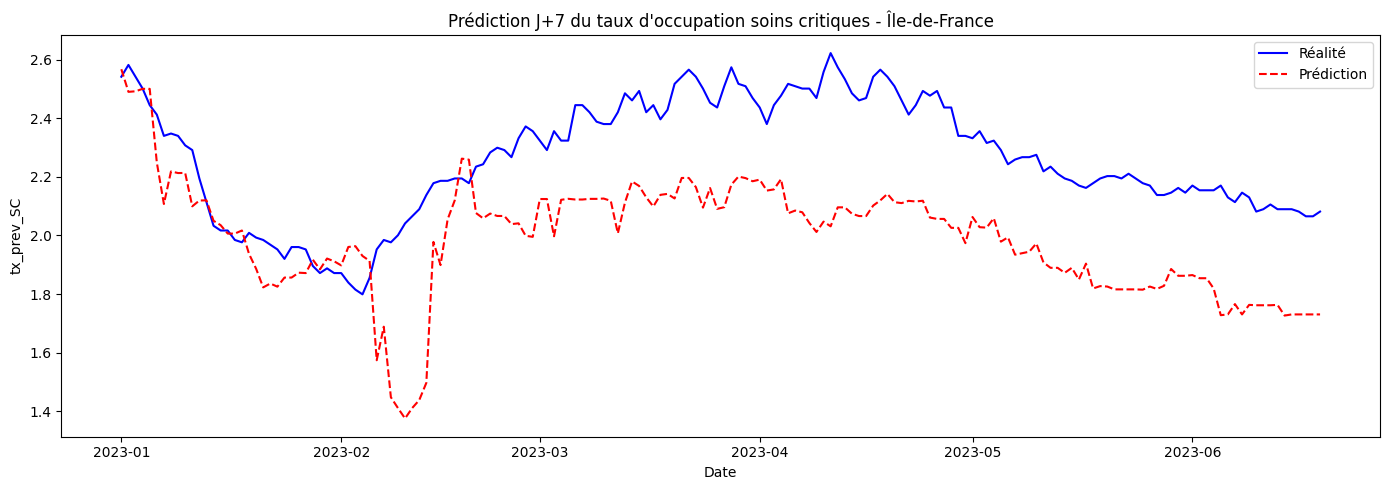

In [8]:
# Visualiser prédictions vs réalité
plt.figure(figsize=(14, 5))
plt.plot(test["jour"].values, y_test.values, label="Réalité", color="blue")
plt.plot(test["jour"].values, y_pred, label="Prédiction", color="red", linestyle="--")
plt.title("Prédiction J+7 du taux d'occupation soins critiques - Île-de-France")
plt.xlabel("Date")
plt.ylabel("tx_prev_SC")
plt.legend()
plt.tight_layout()
plt.show()

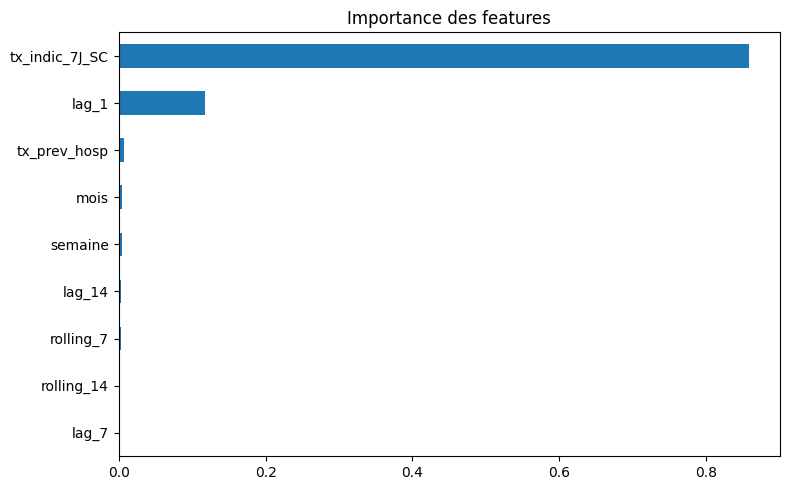

In [9]:


importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind="barh", figsize=(8, 5), title="Importance des features")
plt.tight_layout()
plt.show()

In [10]:
# Retirer tx_indic_7J_SC des features
features = ["lag_1", "lag_7", "lag_14", "rolling_7", "rolling_14", 
            "mois", "semaine", "tx_prev_hosp"]

X_train = train[features]
y_train = train["cible"]
X_test = test[features]
y_test = test["cible"]

# Réentraîner
model2 = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

mae2 = mean_absolute_error(y_test, y_pred2)
rmse2 = root_mean_squared_error(y_test, y_pred2)

print(f"MAE  : {mae2:.3f}")
print(f"RMSE : {rmse2:.3f}")

MAE  : 0.131
RMSE : 0.161


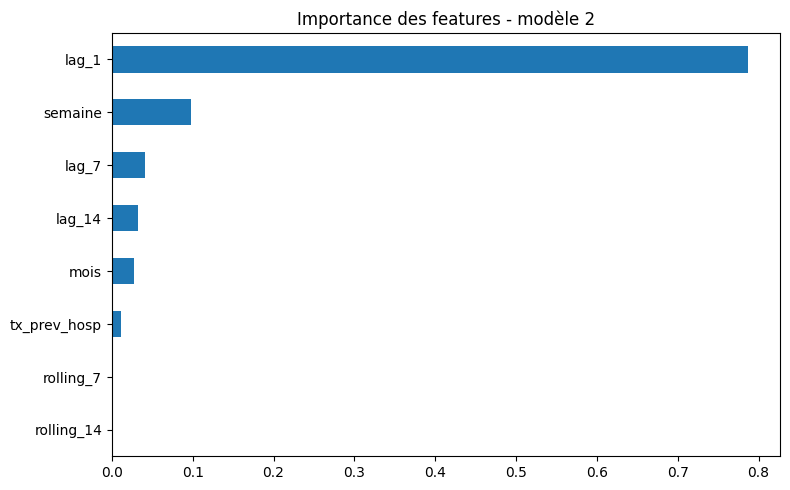

In [11]:
importances2 = pd.Series(model2.feature_importances_, index=features)
importances2.sort_values().plot(kind="barh", figsize=(8, 5), title="Importance des features - modèle 2")
plt.tight_layout()
plt.show()

In [12]:
# Features sans les variables dominantes et inutiles
features = ["lag_7", "lag_14", "mois", "semaine", "tx_prev_hosp"]

X_train = train[features]
y_train = train["cible"]
X_test = test[features]
y_test = test["cible"]

# Réentraîner
model3 = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

mae3 = mean_absolute_error(y_test, y_pred3)
rmse3 = root_mean_squared_error(y_test, y_pred3)

print(f"MAE  : {mae3:.3f}")
print(f"RMSE : {rmse3:.3f}")

MAE  : 0.457
RMSE : 0.498


In [13]:
# Tableau comparatif des modèles
resultats = pd.DataFrame({
    "Modèle": ["XGBoost toutes features", "XGBoost sans tx_indic_7J_SC", "XGBoost sans lag_1"],
    "MAE": [0.285, 0.131, 0.457],
    "RMSE": [0.319, 0.161, 0.498]
})
print(resultats.to_string(index=False))

                     Modèle   MAE  RMSE
    XGBoost toutes features 0.285 0.319
XGBoost sans tx_indic_7J_SC 0.131 0.161
         XGBoost sans lag_1 0.457 0.498


MAE  : 0.633
RMSE : 0.669


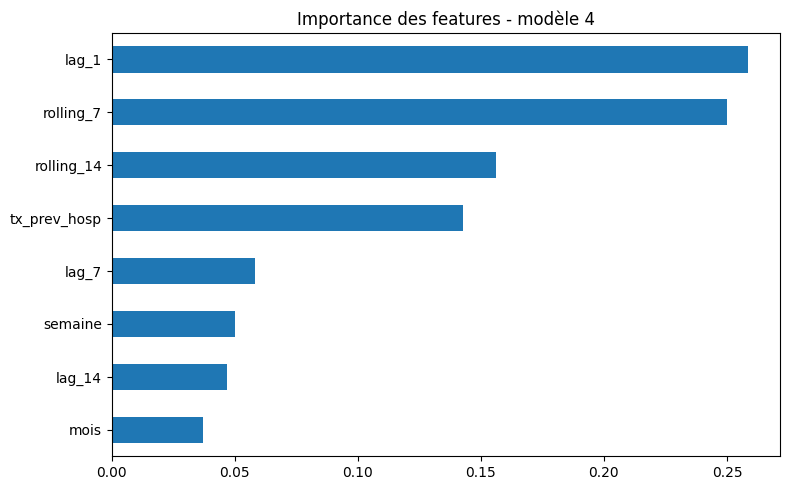

In [14]:
model4 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,      # plus lent
    max_depth=4,             # arbres moins profonds
    subsample=0.8,           # 80% des lignes par arbre
    colsample_bytree=0.6,    # 60% des features par arbre
    random_state=42
)

features = ["lag_1", "lag_7", "lag_14", "rolling_7", "rolling_14", 
            "mois", "semaine", "tx_prev_hosp"]

X_train = train[features]
X_test = test[features]

model4.fit(X_train, y_train)
y_pred4 = model4.predict(X_test)

mae4 = mean_absolute_error(y_test, y_pred4)
rmse4 = root_mean_squared_error(y_test, y_pred4)

print(f"MAE  : {mae4:.3f}")
print(f"RMSE : {rmse4:.3f}")

# Importance des features
importances4 = pd.Series(model4.feature_importances_, index=features)
importances4.sort_values().plot(kind="barh", figsize=(8, 5), title="Importance des features - modèle 4")
plt.tight_layout()
plt.show()

In [15]:
resultats = pd.DataFrame({
    "Modèle": [
        "XGBoost toutes features", 
        "XGBoost sans tx_indic_7J_SC ✅", 
        "XGBoost sans lag_1",
        "XGBoost régularisé"
    ],
    "MAE": [0.285, 0.131, 0.457, 0.633],
    "RMSE": [0.319, 0.161, 0.498, 0.669]
})
print(resultats.to_string(index=False))

                       Modèle   MAE  RMSE
      XGBoost toutes features 0.285 0.319
XGBoost sans tx_indic_7J_SC ✅ 0.131 0.161
           XGBoost sans lag_1 0.457 0.498
           XGBoost régularisé 0.633 0.669
